In [1]:
from pathlib import Path
import typing

import numpy as np
import matplotlib.pyplot as plt
#%matplotlib widget
%matplotlib inline

from scipy.optimize import curve_fit
import scipy.integrate as integrate

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.sourcespectrum import SourceSpectrum
from spectra.utilities import ArrayParams

# ArrayParams class

In [3]:
# class ArrayParams(typing.NamedTuple):
#     """Container with named attributes for making 1D arrays of values.
#     Intended for use with numpy.linspace.
#     """
#     min_value: float
#     max_value: float
#     num_pnts: int
        
temp = ArrayParams(300, 440, 11)
temp.min_value

300

In [3]:
print(*temp)

300 440 11


In [4]:
np.linspace(*temp)

array([300., 314., 328., 342., 356., 370., 384., 398., 412., 426., 440.])

# Irradiance class

In [5]:
class Irradiance:
    """Callable class that calculates the irradiance over an array of 
    wavelengths for a given value of z in microns.
    
    Parameters
    ----------
    source - SourceSpectrum
        Spectrum of source
    resin - Resin
        Resin light propagates through
    wavelength_array_params - ArrayParams
        Minimum, maximum wavelength and number of points for array of wavelengths
        
        
    Example
    -------
        # Create irradiance object for particular source, resin, and wavelength parameters
        irradiance = Irradiance(
            source=source,
            resin=resin,
            wavelength_array_params=wavelength_array_parameters
        )
        # Calculate the irradiance over wavelength array
        irradiance_at_z_10_um = irradiance(10)
        # Plot irradiance
        fig, ax = plt.subplots()
        ax.plot(irradiance.wavelengths, irradiance_at_z_10_um)
    """
    
    def __init__(self, source, resin, wavelength_array_params):
        
        assert isinstance(source, SourceSpectrum)
        assert isinstance(resin, Resin)
        assert isinstance(wavelength_array_params, ArrayParams)
        
        self.source = source
        self.resin = resin
        self.wavelength_array_params = wavelength_array_params
        
        self.wavelengths = np.linspace(*self.wavelength_array_params)
        
        self.source_spectrum = self.source.calc_power(self.wavelengths)
        self.absorption_coeff_inv_um = self.resin.calc_absorption_coef_inv_um(self.wavelengths)
        
    def __call__(self, z_um):
        assert isinstance(z_um, (float, int))
        temp = self.source_spectrum * np.exp(-self.absorption_coeff_inv_um * z_um)
        return temp
        

## 365 nm LED with 370 nm short pass filter

In [6]:
plot_directory = Path('200328_plots')
plot_directory.resolve()

PosixPath('/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/notebooks/200328_plots')

In [7]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    0.38
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin = Resin(monomers=pegda, absorbers=avobenzone, photoinitiators=irgacure819)
print(resin.name)

# Source
source = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']

# Wavelength array parameters
wavelength_array_parameters = ArrayParams(300, 440, 401)

irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=wavelength_array_parameters)

PEG-100__Avo-0.38__Irg-1


In [8]:
np.allclose(irradiance(0), source.calc_power(np.linspace(*wavelength_array_parameters)))

True

In [9]:
z_um_values = np.linspace(0, 60, 11)

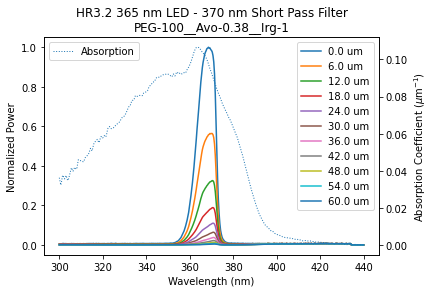

In [10]:
fig, ax = plt.subplots()
for z_um in z_um_values:
    ax.plot(irradiance.wavelengths, irradiance(z_um), label=f"{z_um} um")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Power")
ax2 = ax.twinx()
ax2.plot(irradiance.wavelengths, resin.calc_absorption_coef_inv_um(irradiance.wavelengths), \
         lw=1, ls=':', label='Absorption')
ax2.set_ylabel("Absorption Coefficient ($\mu$m$^{-1}$)")
ax2.legend(loc="upper left")
ax.set_title("HR3.2 365 nm LED - 370 nm Short Pass Filter\n" + resin.name)
ax.legend();
# plt.savefig(plot_directory.resolve() / '365nm_short_pass_filter.png')

In [11]:
irradiance.wavelengths[1] - irradiance.wavelengths[0]

0.35000000000002274

## 365 nm LED - no filter

In [19]:
# Source
source2 = data.sources['HR3.2_365nm_no_filter-2019-12-31']

irradiance2 = Irradiance(source=source2, resin=resin, wavelength_array_params=wavelength_array_parameters)

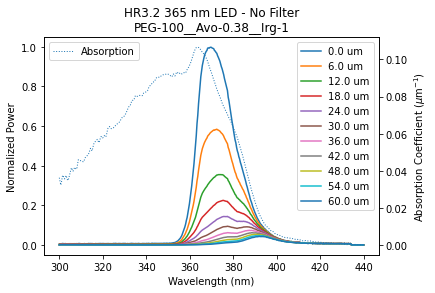

In [26]:
fig, ax = plt.subplots()
for z_um in z_um_values:
    ax.plot(irradiance2.wavelengths, irradiance2(z_um), label=f"{z_um} um")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Power")
ax2 = ax.twinx()
ax2.plot(irradiance2.wavelengths, resin.calc_absorption_coef_inv_um(irradiance2.wavelengths), \
         lw=1, ls=':', label='Absorption')
ax2.set_ylabel("Absorption Coefficient ($\mu$m$^{-1}$)")
ax2.legend(loc="upper left")
ax.set_title("HR3.2 365 nm LED - No Filter\n" + resin.name)
ax.legend()
# plt.savefig(plot_directory.resolve() / '365nm_no_filter.png')

In [21]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x7fed889b3190>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7feda84abe10>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7fed889b3850>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fed889b3550>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7fed8898e150>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7fed8899e050>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fed8899e490>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fed88997990>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fed889a4050>,
 'HR3.3_365nm_through_tray_no_filter-2020-03-23': <spectra.sourcespectrum.S

## 385 nm LED

In [22]:
# Source
source3 = data.sources['HR2_385nm_2020-03-23']

irradiance3 = Irradiance(source=source3, resin=resin, wavelength_array_params=wavelength_array_parameters)

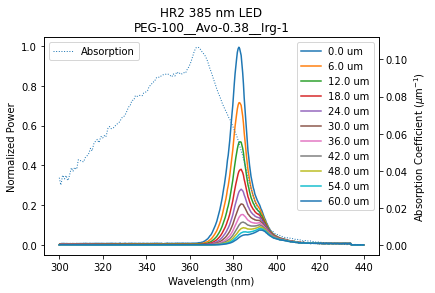

In [27]:
fig, ax = plt.subplots()
for z_um in z_um_values:
    ax.plot(irradiance3.wavelengths, irradiance3(z_um), label=f"{z_um} um")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Power")
ax2 = ax.twinx()
ax2.plot(irradiance3.wavelengths, resin.calc_absorption_coef_inv_um(irradiance3.wavelengths), \
         lw=1, ls=':', label='Absorption')
ax2.set_ylabel("Absorption Coefficient ($\mu$m$^{-1}$)")
ax2.legend(loc="upper left")
ax.set_title("HR2 385 nm LED\n" + resin.name)
ax.legend();
# plt.savefig(plot_directory.resolve() / '385nm.png')

## 405 nm LED

In [28]:
# Source
source4 = data.sources['Asiga_405nm_100um_fiber-2016-12-14']

irradiance4 = Irradiance(source=source4, resin=resin, wavelength_array_params=wavelength_array_parameters)

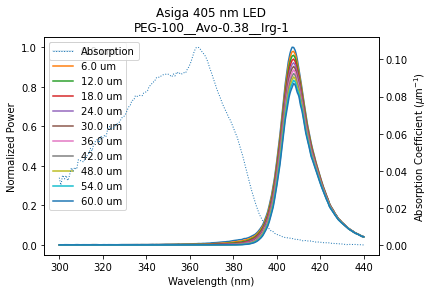

In [29]:
fig, ax = plt.subplots()
for z_um in z_um_values:
    ax.plot(irradiance4.wavelengths, irradiance4(z_um), label=f"{z_um} um")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Power")
ax2 = ax.twinx()
ax2.plot(irradiance4.wavelengths, resin.calc_absorption_coef_inv_um(irradiance4.wavelengths), \
         lw=1, ls=':', label='Absorption')
ax2.set_ylabel("Absorption Coefficient ($\mu$m$^{-1}$)")
ax2.legend(loc="upper left")
ax.set_title("Asiga 405 nm LED\n" + resin.name)
ax.legend();
# plt.savefig(plot_directory.resolve() / '405nm.png')